# 01 — ECG Dataset Exploration

## Objective

The objective of this notebook is to establish a clear understanding of
the ECG dataset and inspect the raw ECG signal before applying any
signal-processing algorithms.

We will:

1. Acquire the MIT-BIH Arrhythmia Database.
2. Store the raw dataset locally.
3. Understand the structure of the WFDB files.
4. Load and inspect record 100.
5. Examine the recording metadata.
6. Characterize the signal numerically.
7. Visualize the raw ECG in the time domain.
8. Examine its discrete-time representation.
9. Inspect its frequency-domain representation using the FFT.
10. Verify FFT/IFFT reconstruction.
11. Load the reference annotations.
12. Visualize the annotations alongside the ECG.

No ECG filtering, QRS detection, or feature extraction will be performed
in this notebook.

The purpose of this stage is to understand the data before processing it.

## 1. Imports & Environment

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

In [ ]:
# Define the project paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MITDB_DIR = RAW_DATA_DIR / "mit-bih-arrhythmia"

print("Project root:", PROJECT_ROOT)
print("MIT-BIH directory:", MITDB_DIR)

Project root: f:\Desktop\Projects\Programming\ECG-Signal-Processing-and-Analysis
MIT-BIH directory: f:\Desktop\Projects\Programming\ECG-Signal-Processing-and-Analysis\data\raw\mit-bih-arrhythmia


## 2. Download the database

In [3]:
# Create the needed directory
MITDB_DIR.mkdir(parents=True, exist_ok=True)
print("Directory ready:", MITDB_DIR)

Directory ready: f:\Desktop\Projects\Programming\ECG-Signal-Processing-and-Analysis\data\raw\mit-bih-arrhythmia


In [4]:
# Download the MIT-BIH Arrhythmia Database from PhysioNet
wfdb.dl_database(
    "mitdb",
    dl_dir=str(MITDB_DIR)
)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
# Inspect 
files = sorted(MITDB_DIR.iterdir())

print(f"Number of files: {len(files)}")

for file in files[:20]:
    print(file.name)

Number of files: 144
100.atr
100.dat
100.hea
101.atr
101.dat
101.hea
102.atr
102.dat
102.hea
103.atr
103.dat
103.hea
104.atr
104.dat
104.hea
105.atr
105.dat
105.hea
106.atr
106.dat


| File      | Meaning                                           |
| --------- | ------------------------------------------------- |
| `100.dat` | Actual sampled ECG signal data                    |
| `100.hea` | Header/metadata about the recording               |
| `100.atr` | Reference annotations, including beat annotations |


## 3. Load and Inspect 

In [ ]:
# Load recording 100 and inspect
record = wfdb.rdrecord(str(MITDB_DIR / "100"))

In [ ]:
# Get some fundamental info of the recording
print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)
print("Signal names:", record.sig_name)
print("Units:", record.units)

Sampling frequency: 360
Number of samples: 650000
Number of channels: 2
Signal names: ['MLII', 'V5']
Units: ['mV', 'mV']


In [ ]:
# Calculate the length of the recording in minutes
length_in_min = ((record.sig_len/record.fs)/60)
print("Length of the recording in minutes:", length_in_min)

Length of the recording in minutes: 30.092592592592595


In [ ]:
record.p_signal.shape   # Check the shape

(650000, 2)

In [ ]:
print(record.p_signal[:10]) # Display some samples

[[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.12  -0.08 ]
 [-0.135 -0.08 ]]


In [ ]:
# Compute some statistics for each channel
print("Minimum:", np.min(record.p_signal, axis=0))
print("Maximum:", np.max(record.p_signal, axis=0))
print("Mean:", np.mean(record.p_signal, axis=0))
print("Standard deviation:", np.std(record.p_signal, axis=0))

Minimum: [-2.715 -2.465]
Maximum: [1.435 1.225]
Mean: [-0.30629898 -0.19103443]
Standard deviation: [0.19319954 0.14821322]


## 4. Time-Domain Analysis

#### - plot the entire recording

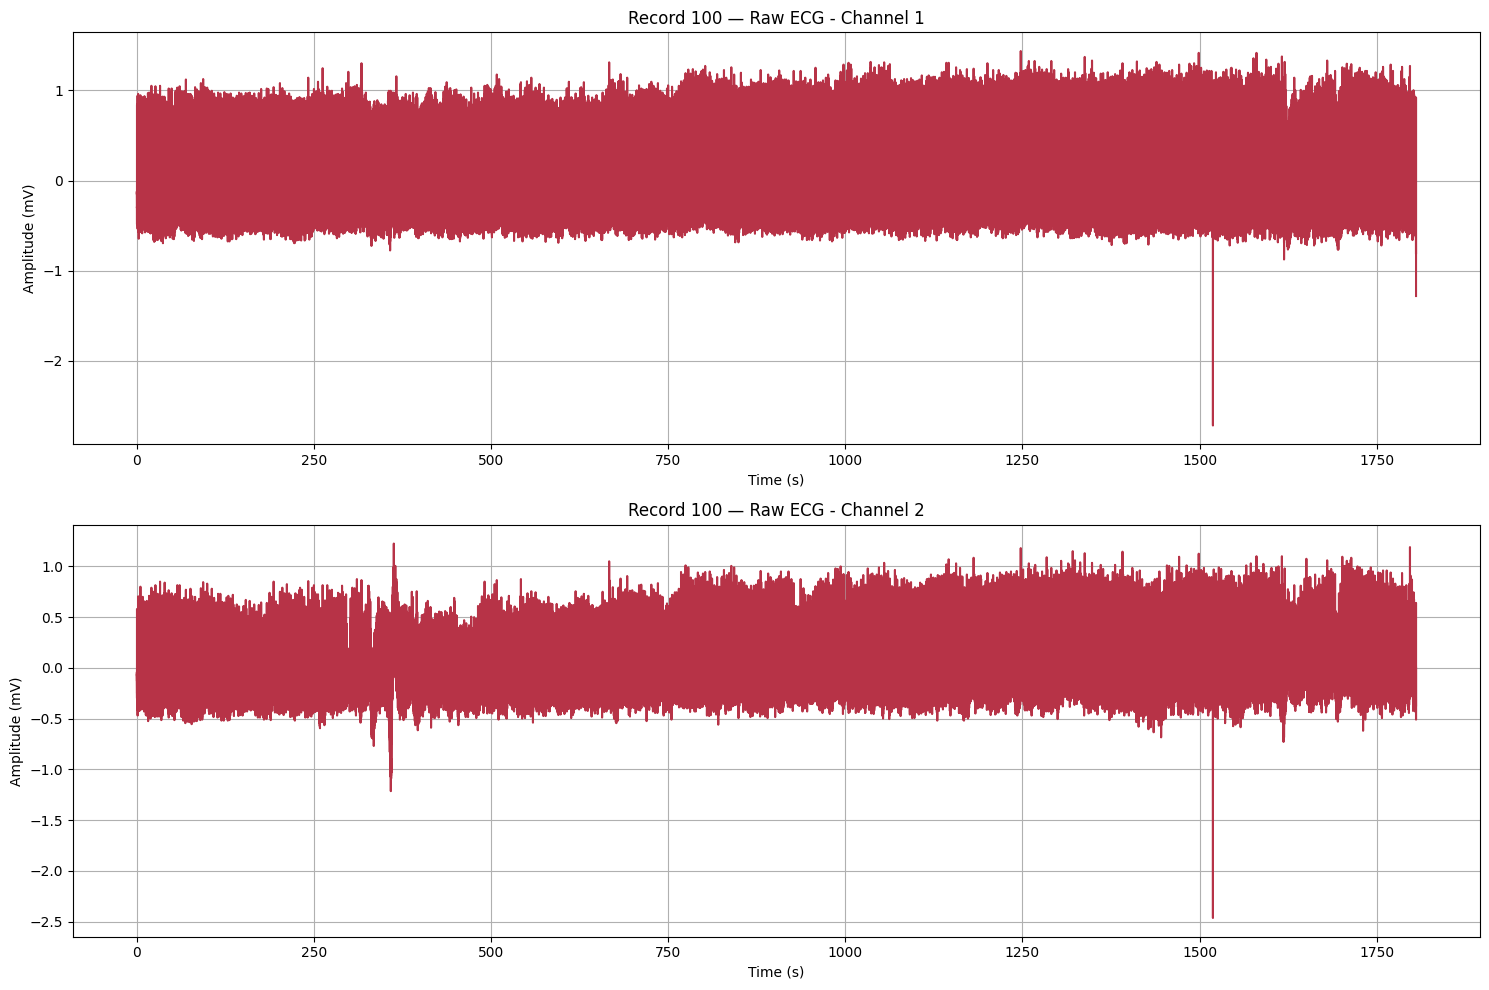

In [ ]:
time = np.arange(record.sig_len) / record.fs    # Calculate time intervals

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(time, record.p_signal[:, 0], color="#b73347")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Raw ECG - Channel 1")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, record.p_signal[:, 1], color="#b73347")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Raw ECG - Channel 2")
plt.grid()

plt.tight_layout()
plt.show()

#### - plot a short segment

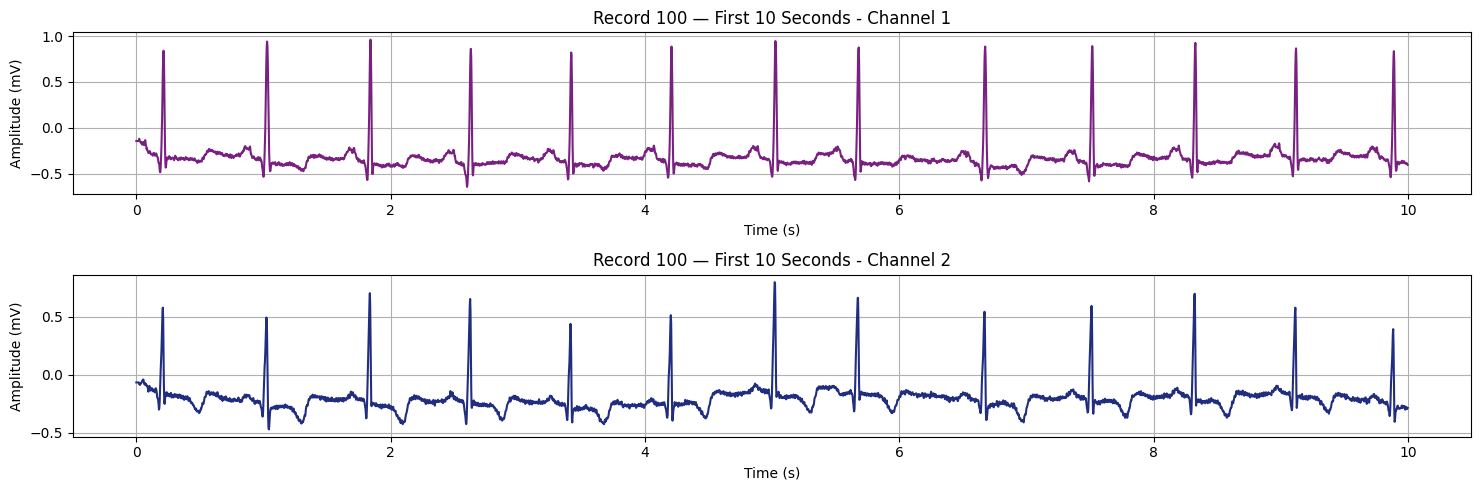

In [131]:
duration = 10
samples = int(duration * record.fs)

plt.figure(figsize=(15, 5))

plt.subplot(2, 1, 1)
plt.plot(time[:samples], record.p_signal[:samples, 0], color="#792180")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — First {duration} Seconds - Channel 1")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time[:samples], record.p_signal[:samples, 1], color="#212E80")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — First {duration} Seconds - Channel 2")
plt.grid()

plt.tight_layout()
plt.show()

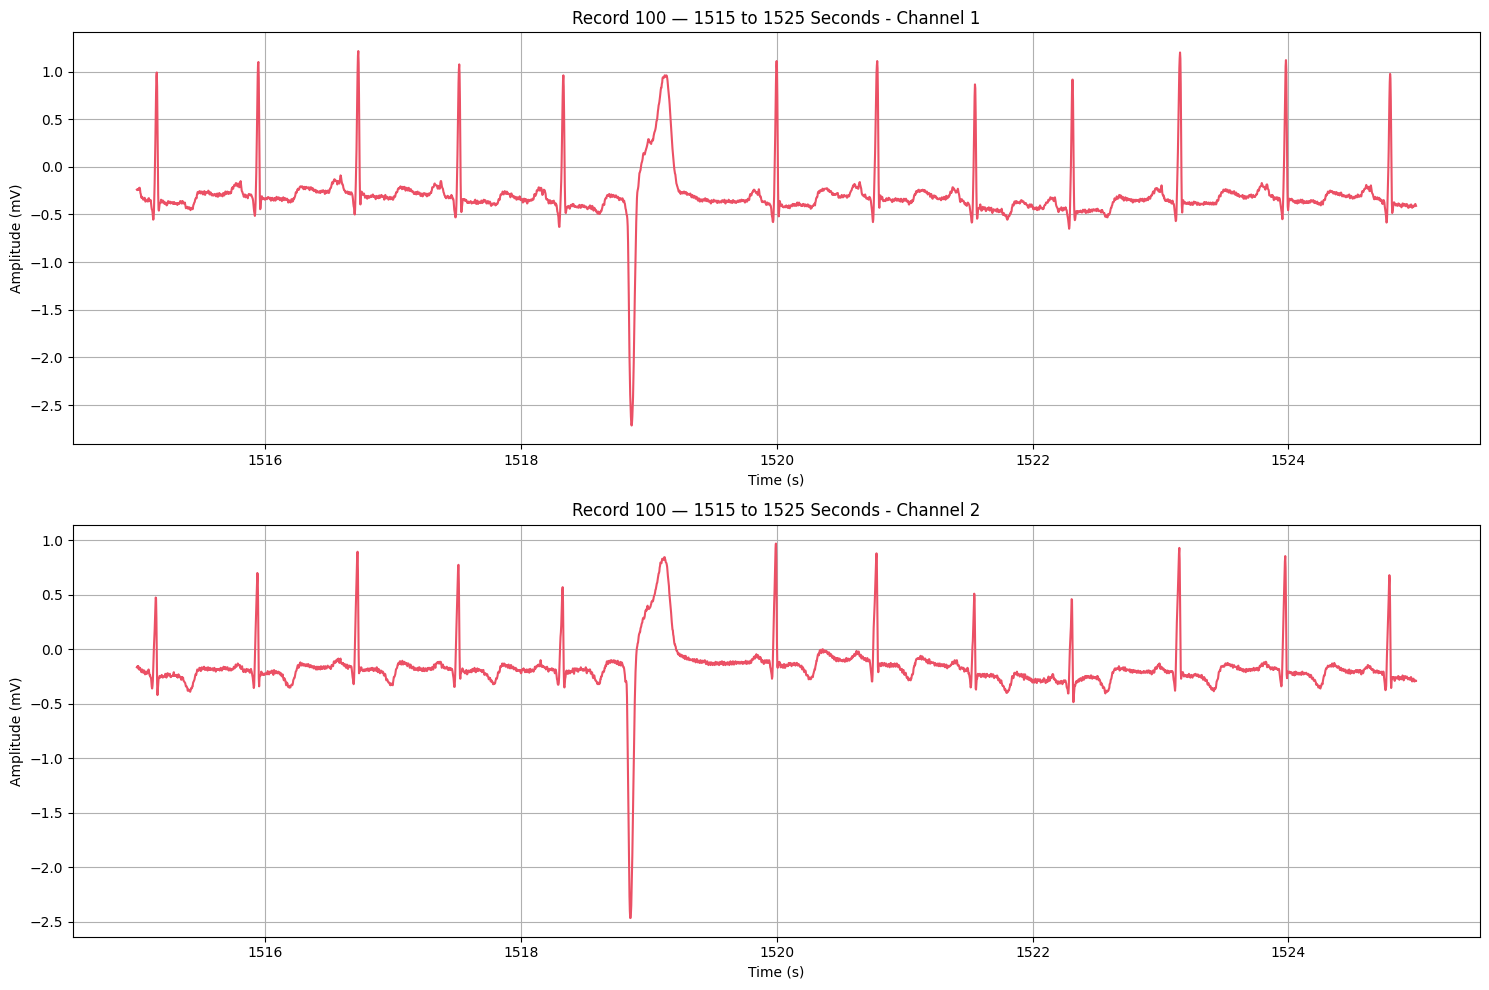

In [ ]:
# Inspect the sharp drop area we observed in the entire record 100 - both channels
start_time = 1515
end_time = 1525

start_sample = int(start_time * record.fs)
end_sample = int(end_time * record.fs)

segment1 = record.p_signal[start_sample:end_sample, 0]
segment2 = record.p_signal[start_sample:end_sample, 1]
segment_time = time[start_sample:end_sample]

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(segment_time, segment1, color="#eb5065")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — {start_time} to {end_time} Seconds - Channel 1")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(segment_time, segment2, color="#eb5065")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — {start_time} to {end_time} Seconds - Channel 2")
plt.grid()

plt.tight_layout()
plt.show()

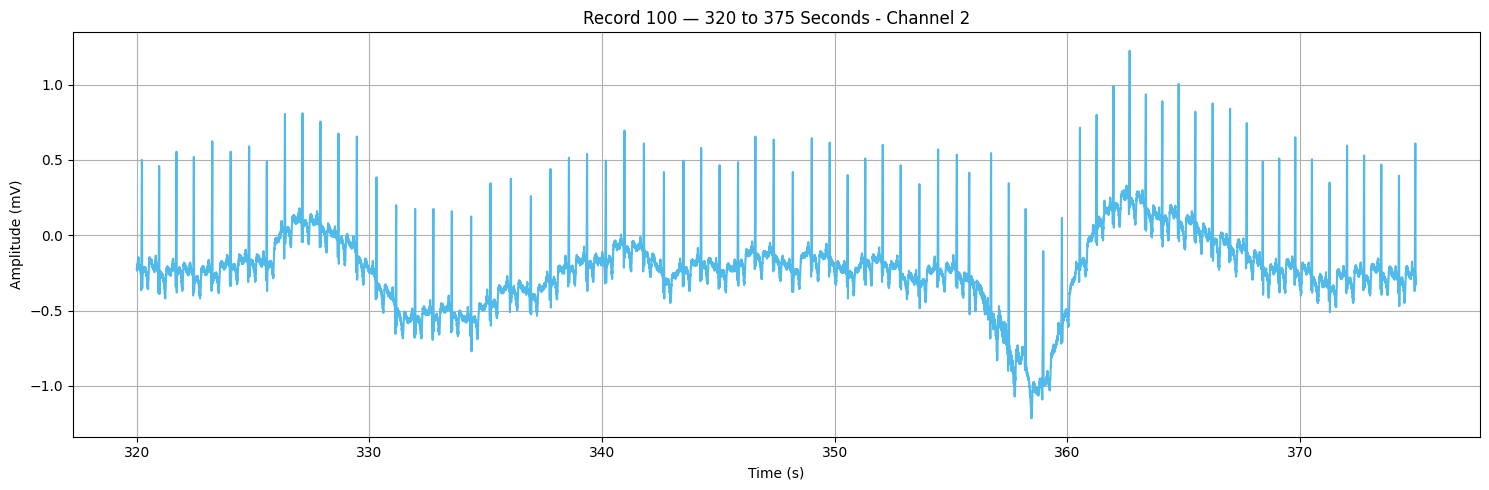

In [104]:
# Inspect the sharp ups and downs area we observed in the entire record 100 - channel 2
start_time_ups_downs = 320
end_time_ups_downs = 375

start_sample_ups_downs = int(start_time_ups_downs * record.fs)
end_sample_ups_downs = int(end_time_ups_downs * record.fs)

segment2_ups_downs = record.p_signal[start_sample_ups_downs:end_sample_ups_downs, 1]
segment_time_ups_downs = time[start_sample_ups_downs:end_sample_ups_downs]

plt.figure(figsize=(15, 5))
plt.plot(segment_time_ups_downs, segment2_ups_downs, color="#50baeb")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — {start_time_ups_downs} to {end_time_ups_downs} Seconds - Channel 2")
plt.grid()

plt.tight_layout()
plt.show()

#### - Discrete-Time Representation

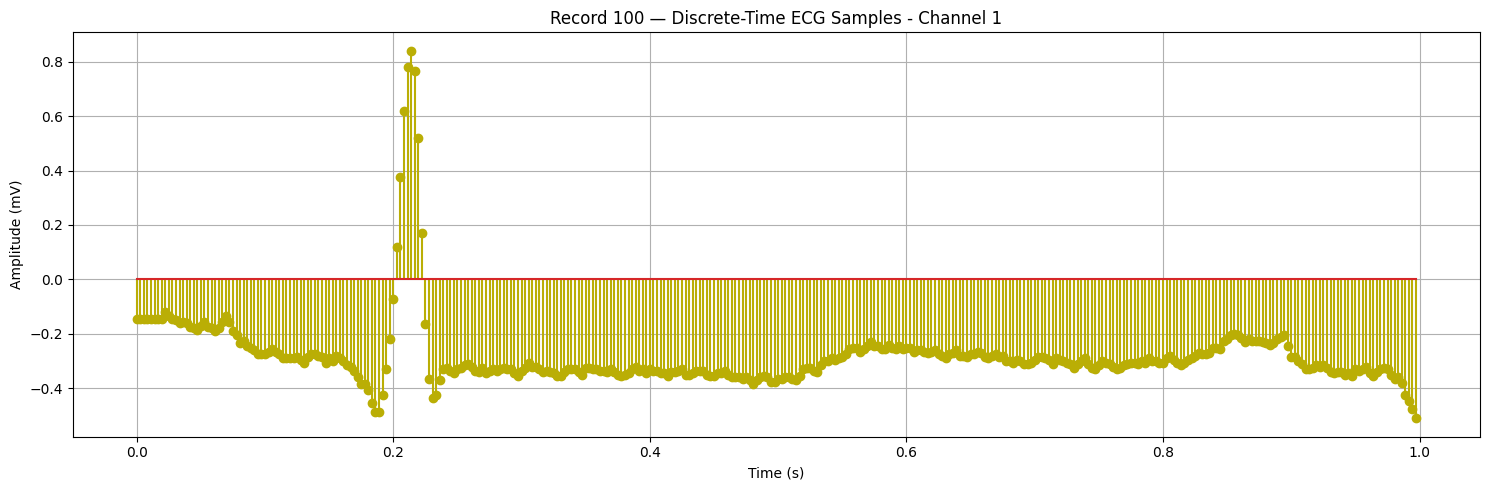

In [129]:
duration_ = 1
#arbt_fs = 100
samples = int(duration_ * record.fs)

plt.figure(figsize=(15, 5))
plt.stem(time[:samples], record.p_signal[:samples, 0], markerfmt="o", linefmt="#baae05")
#plt.plot(time[:samples], record.p_signal[:samples, 0], color="#C10000")    -> Continuous
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Discrete-Time ECG Samples - Channel 1")
plt.grid()
plt.tight_layout()
plt.show()

## 5. Frequency-Domain Analysis

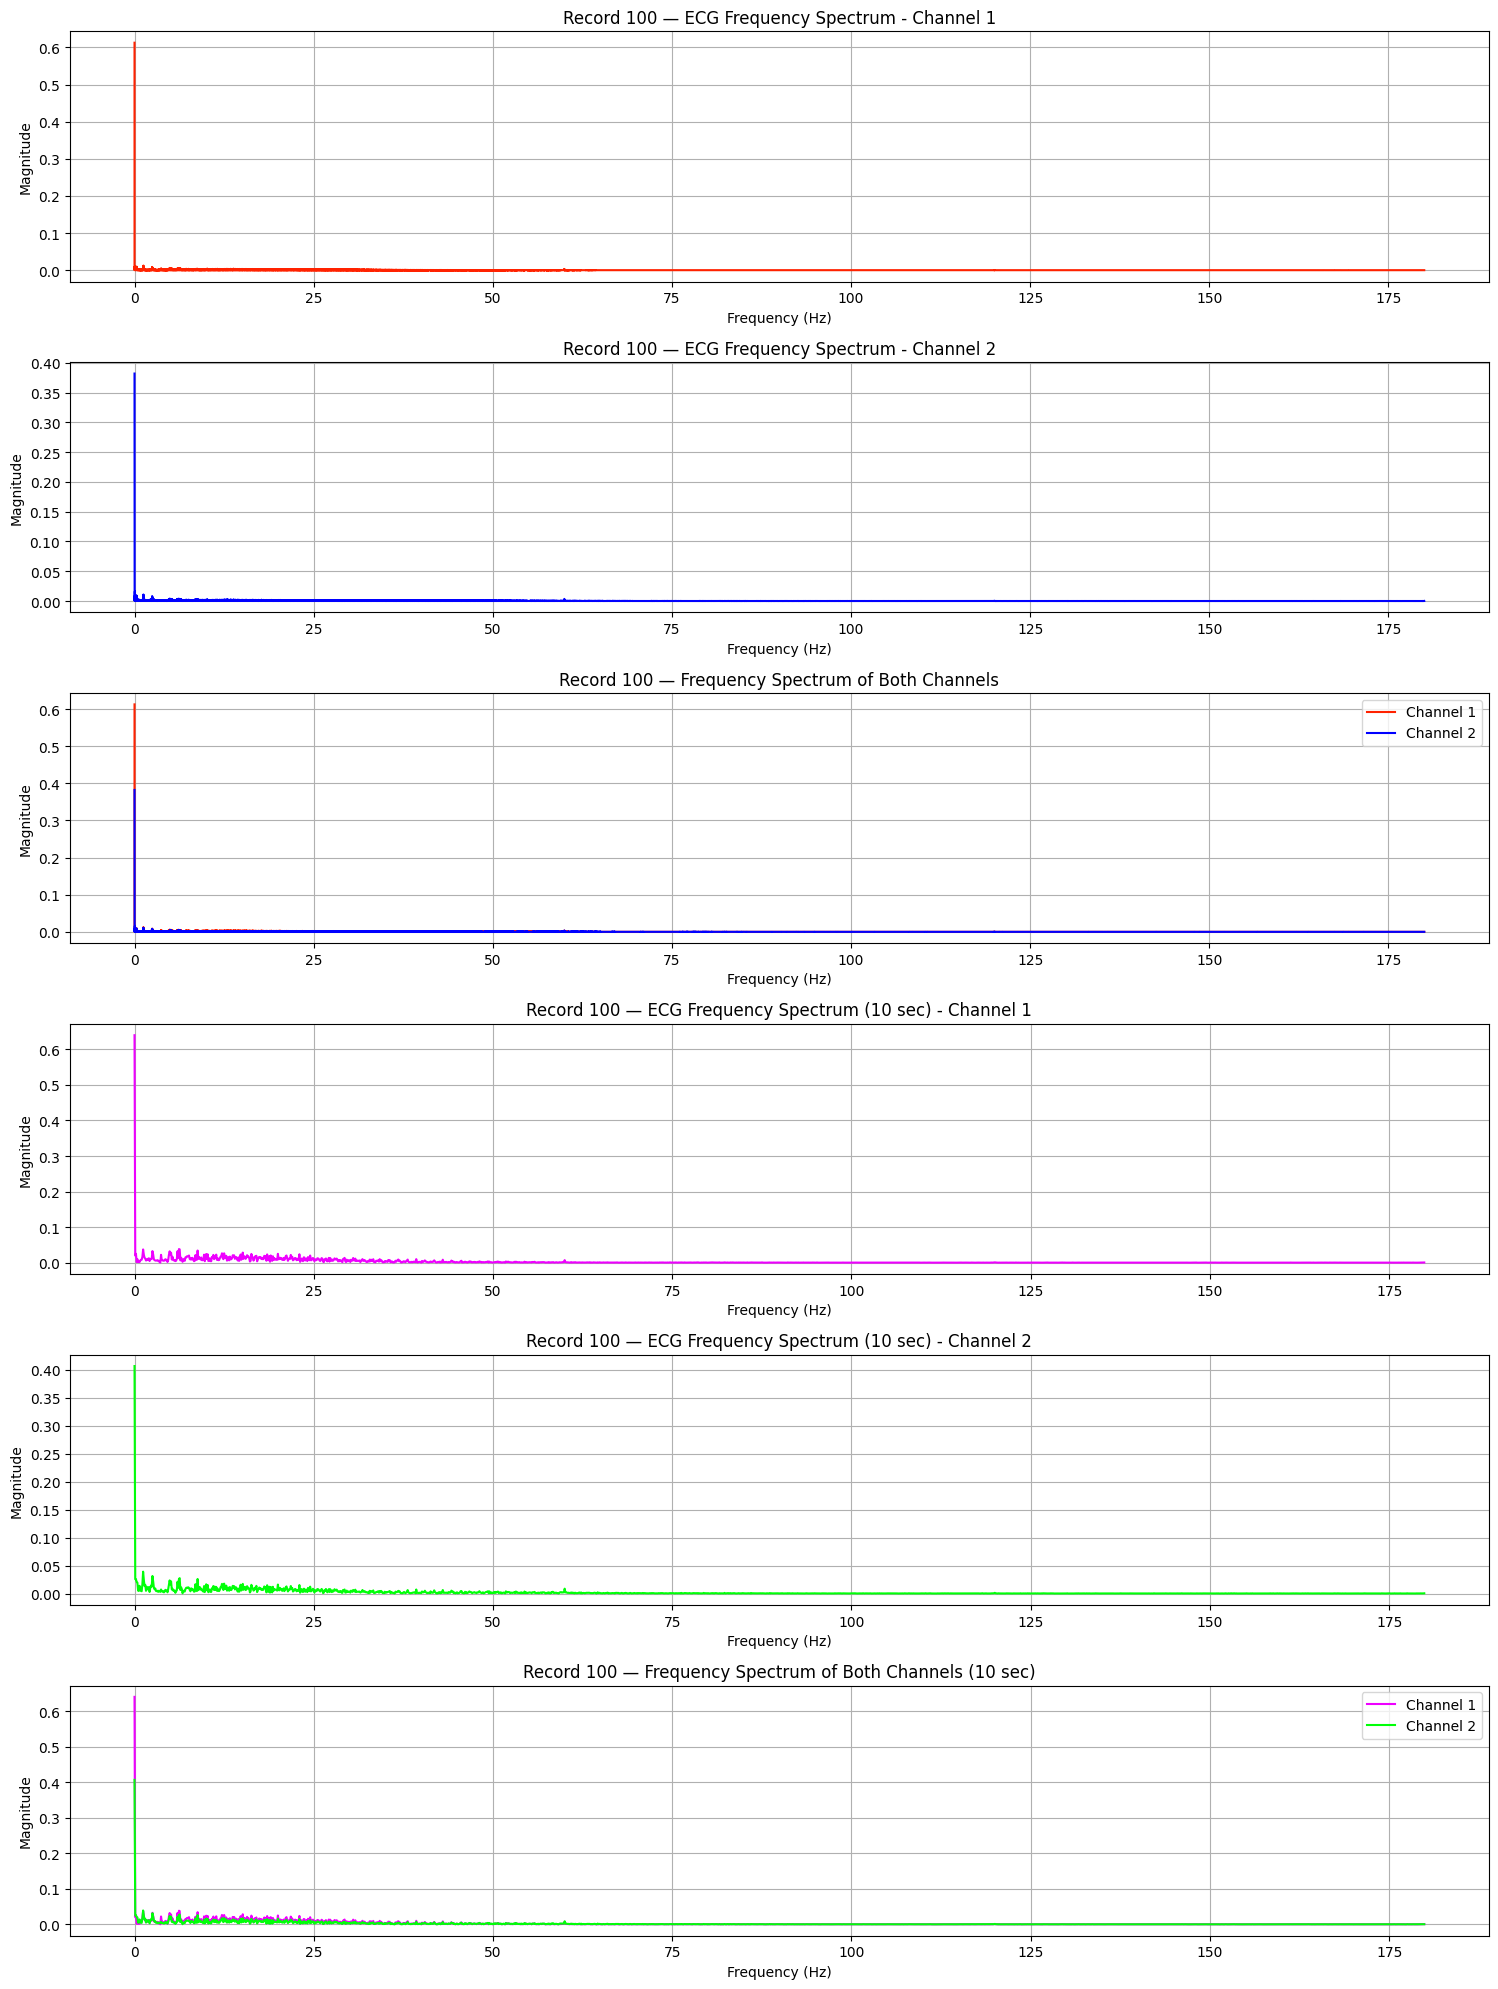

In [ ]:
# Apply fft on the signal(s)
def fft_analysis(signal):
    fft_result = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal), d=1 / signal.fs)
    magnitude = np.abs(fft_result) * 2.0 / len(signal)
    positive = frequencies >= 0

    return frequencies, magnitude, positive

# Entire record
entire_channel1 = record.p_signal[:, 0]
entire_channel2 = record.p_signal[:, 1]

# 10 sec segment
ten_sec_channel1 = record.p_signal[:samples, 0]
ten_sec_channel2 = record.p_signal[:samples, 1]

freq1, mag1, pos1 = fft_analysis(entire_channel1)
freq2, mag2, pos2 = fft_analysis(entire_channel2)

freq_ten_1, mag_ten_1, pos_ten_1 = fft_analysis(ten_sec_channel1)
freq_ten_2, mag_ten_2, pos_ten_2 = fft_analysis(ten_sec_channel2)


plt.figure(figsize=(15, 20))

# Plot of the entire recording
plt.subplot(6, 1, 1)
plt.plot(freq1[pos1], mag1[pos1], color="#ff2200")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum - Channel 1")
plt.grid()

plt.subplot(6, 1, 2)
plt.plot(freq2[pos2], mag2[pos2], color="#0000ff")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum - Channel 2")
plt.grid()

plt.subplot(6, 1, 3)
plt.plot(freq1[pos1], mag1[pos1], label="Channel 1", color="#ff2200")
plt.plot(freq2[pos2], mag2[pos2], label="Channel 2", color="#0000ff")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — Frequency Spectrum of Both Channels")
plt.legend()
plt.grid()

# Plot of first 10 seconds segment
plt.subplot(6, 1, 4)
plt.plot(freq_ten_1[pos_ten_1], mag_ten_1[pos_ten_1], color="#ee00ff")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum (10 sec) - Channel 1")
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(freq_ten_2[pos_ten_2], mag_ten_2[pos_ten_2], color="#00ff08")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum (10 sec) - Channel 2")
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(freq_ten_1[pos_ten_1], mag_ten_1[pos_ten_1], label="Channel 1", color="#ee00ff")
plt.plot(freq_ten_2[pos_ten_2], mag_ten_2[pos_ten_2], label="Channel 2", color="#00ff08")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — Frequency Spectrum of Both Channels (10 sec)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


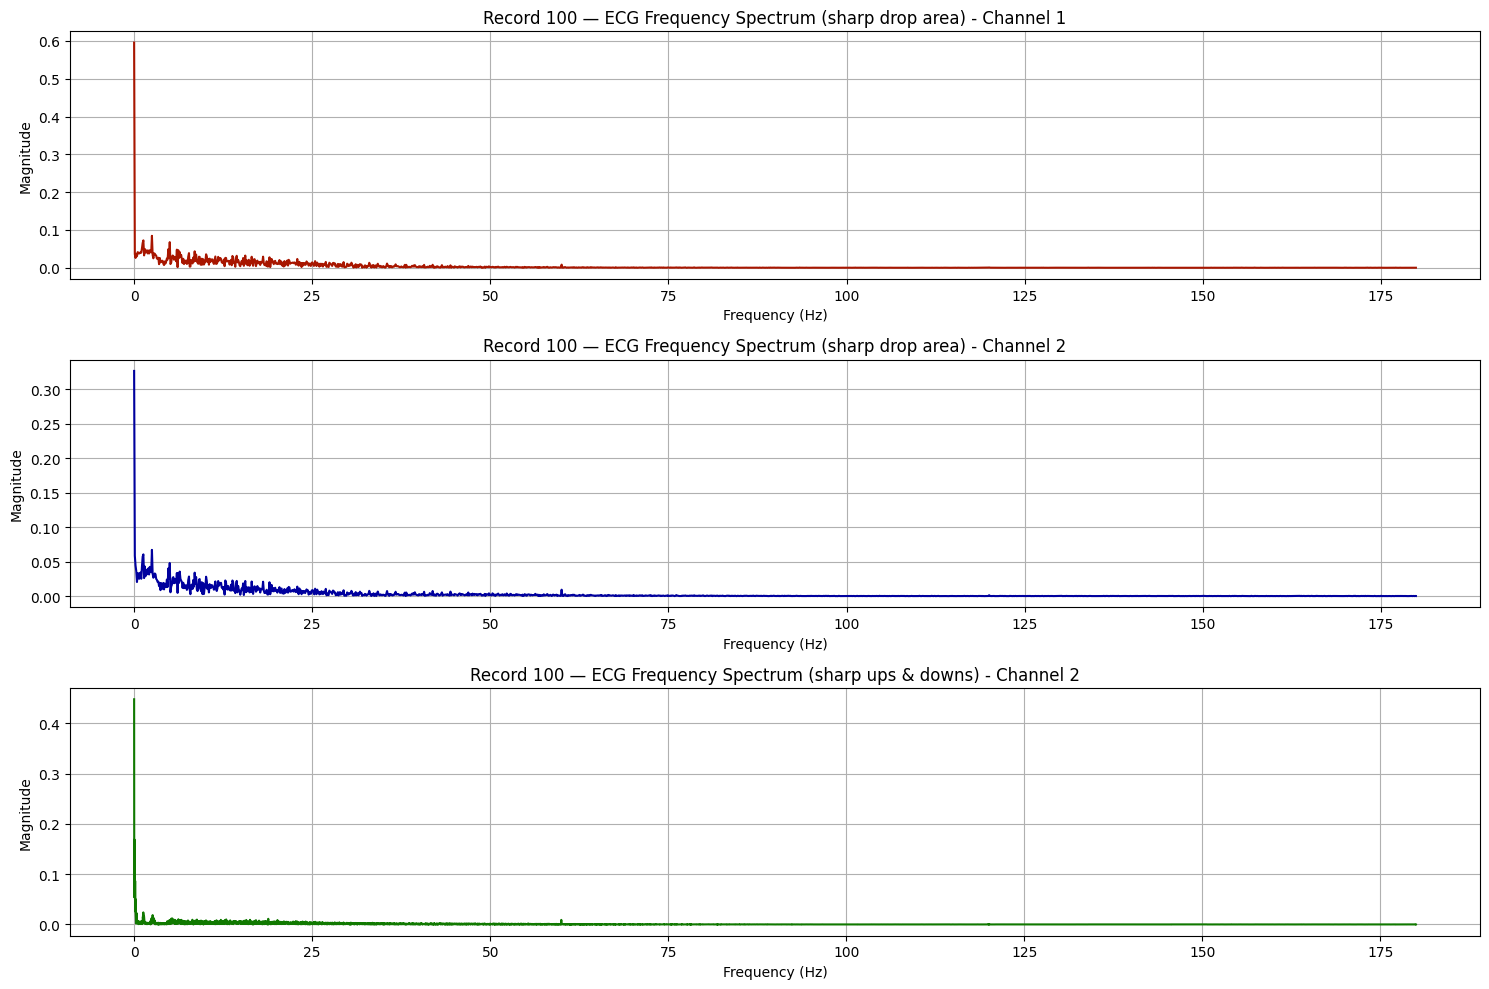

In [138]:
# Apply fft on the areas that we want to inspect more: sharp ups and downs

freq_seg_1, mag_seg_1, pos_seg_1 = fft_analysis(segment1)
freq_seg_2, mag_seg_2, pos_seg_2 = fft_analysis(segment2)
freq_seg_ud_2, mag_seg_ud_2, pos_seg_ud_2 = fft_analysis(segment2_ups_downs)


plt.figure(figsize=(15, 10))

# Plot of the entire recording
plt.subplot(3, 1, 1)
plt.plot(freq_seg_1[pos_seg_1], mag_seg_1[pos_seg_1], color="#a81600")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum (sharp drop area) - Channel 1")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(freq_seg_2[pos_seg_2], mag_seg_2[pos_seg_2], color="#00009e")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum (sharp drop area) - Channel 2")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(freq_seg_ud_2[pos_seg_ud_2], mag_seg_ud_2[pos_seg_ud_2], color="#107900")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Record 100 — ECG Frequency Spectrum (sharp ups & downs) - Channel 2")
plt.grid()

plt.tight_layout()
plt.show()

## 6. Reference Annotations

### - Load and Inspect

In [154]:
# Loaf the annotations
annotations = wfdb.rdann(str(MITDB_DIR / "100"), "atr")

In [155]:
# Inspect
print("Number of annotations:", len(annotations.sample))
print("Annotation symbols:", np.unique(annotations.symbol))

Number of annotations: 2274
Annotation symbols: ['+' 'A' 'N' 'V']


| Symbol | Meaning                                                                  |
| ------ | ------------------------------------------------------------------------ |
| `N`    | **Normal beat**                                                          |
| `V`    | **Premature ventricular contraction (PVC)** — a ventricular ectopic beat |
| `A`    | **Atrial premature beat (APB)** — an atrial ectopic beat                 |
| `+`    | **Rhythm change / rhythm annotation**, rather than a heartbeat itself    |


In [ ]:
# Sample: the sample indices at which annotations occur 
# Symbol: the corresponding annotation symbols
print(annotations.sample[:20])
print(annotations.symbol[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [157]:
# Convert annotation samples to time --> N = T . Fs --> T = N / Fs
annotation_times = annotations.sample / record.fs

print(annotation_times[:20])

[ 0.05        0.21388889  1.02777778  1.83888889  2.62777778  3.41944444
  4.20833333  5.025       5.67777778  6.67222222  7.51666667  8.32777778
  9.11666667  9.88888889 10.72777778 11.58333333 12.40555556 13.23333333
 14.05555556 14.85      ]


### - Visualize ECG + Annotations

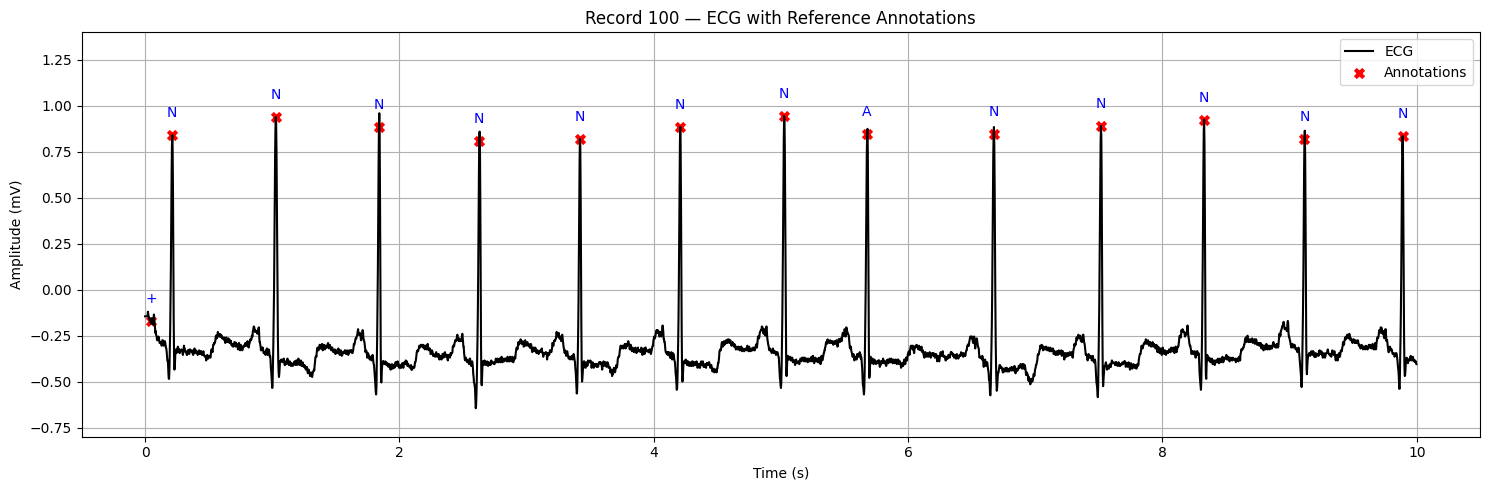

In [179]:
# Get annotations within n number of samples (samples = 3600 as previous calculations for 10 sec segment)
mask = annotations.sample < samples
annotation_samples = annotations.sample[mask]
# Convert to time
annotation_times = annotation_samples / record.fs
annotation_symbols = [symbol for symbol, selected in zip(annotations.symbol, mask) if selected]

plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ten_sec_channel1, label="ECG", color="k")

for sample, symbol in zip(annotation_samples, annotation_symbols):
    plt.annotate(symbol, (sample / record.fs, record.p_signal[sample, 0]), xytext=(0, 13), textcoords="offset points", ha="center", c="b")

plt.scatter(annotation_times, record.p_signal[annotation_samples, 0], marker="x", c="r", linewidth=3, label="Annotations")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — ECG with Reference Annotations")
plt.ylim(-0.8, 1.4)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Initial Observations

- Record 100 contains two ECG channels sampled at 360 Hz.
- The recording duration is approximately 30 minutes.
- The raw ECG was inspected in both the time and frequency domains.
- The two channels exhibit similar cardiac activity but different signal characteristics.
- The frequency spectrum is concentrated primarily in the lower-frequency region, although higher-frequency components are also present.
- Specific regions of the recording showed unusual waveform behavior and were inspected separately.
- The dataset provides reference annotations associated with the ECG recording.
- No filtering, QRS detection, or feature extraction was performed as part of this notebook.